# AI Powered Intelligent Hiring Assistant

Name: Deeptesh Mohapatra

Dataset: Resume Dataset (Kaggle: rayyankauchali0/resume-dataset) - 3,500 resumes labelled with
36 job categories, each with skills, a summary, experience and the full resume text.

This is an end to end system that looks at a candidate's resume against a job's requirements and
helps with hiring. It brings together everything from the earlier weeks:

1. A machine learning model that reads a resume and predicts which job category it belongs to
   (TF-IDF features with a logistic regression classifier).
2. A deep learning model that does the same job using sentence embeddings and a small neural
   network, so I can compare the two approaches.
3. A matching and scoring step that measures how well a resume fits a specific job description,
   using semantic similarity and a skills gap check.
4. An explainable feedback generator that writes personalized, plain English feedback for a
   candidate using a language model (retrieval based text generation).
5. A conversational interface where a candidate can ask questions about their evaluation and get
   grounded answers.

So the project uses machine learning, deep learning, retrieval based generation, and a chat
interface together in one pipeline.

## Setup

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['HF_HUB_DISABLE_TELEMETRY'] = '1'
os.environ['HF_HUB_DISABLE_PROGRESS_BARS'] = '1'

import json, re, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sentence_transformers import SentenceTransformer
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from transformers.utils import logging as hf_logging
hf_logging.set_verbosity_error()
hf_logging.disable_progress_bar()

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE); tf.random.set_seed(RANDOM_STATE)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)
print('Setup done. TensorFlow', tf.__version__)

C:\Users\lenovo\Desktop\Celebal_Internship\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup done. TensorFlow 2.21.0


## 1. Loading the data

The dataset is a JSONL file (one resume per line). I load it into a pandas DataFrame.

In [2]:
import kagglehub, glob
path = kagglehub.dataset_download('rayyankauchali0/resume-dataset')
jsonl = glob.glob(os.path.join(path, '**', '*.jsonl'), recursive=True)[0]

records = [json.loads(line) for line in open(jsonl, encoding='utf-8') if line.strip()]
df = pd.DataFrame(records)
print('Resumes:', len(df), '| Columns:', list(df.columns))
df[['ResumeID', 'Category', 'Skills', 'Summary']].head()

Resumes: 3500 | Columns: ['ResumeID', 'Category', 'Name', 'Email', 'Phone', 'Location', 'Summary', 'Skills', 'Experience', 'Education', 'Text', 'Source']


,ResumeID,Category,Skills,Summary
0,REAL_0001,Java Developer,"Python, SQL, Git, Linux",jessica claire montgomery street san francisco...
1,REAL_0002,Java Developer,"Python, SQL, Git, Linux",jared arthur maica java developer 17994568777 ...
2,REAL_0003,Java Developer,"Python, SQL, Git, Linux",jessica claire 9 resumesampleexamplecom 555 43...
3,REAL_0004,Java Developer,"Python, SQL, Git, Linux",jessica claire 9 resumesampleexamplecom 555 43...
4,REAL_0005,Java Developer,"Python, SQL, Git, Linux",jessica claire 100 montgomery st 10th floor xx...


### 1.1 Job categories in the data

Number of categories: 36


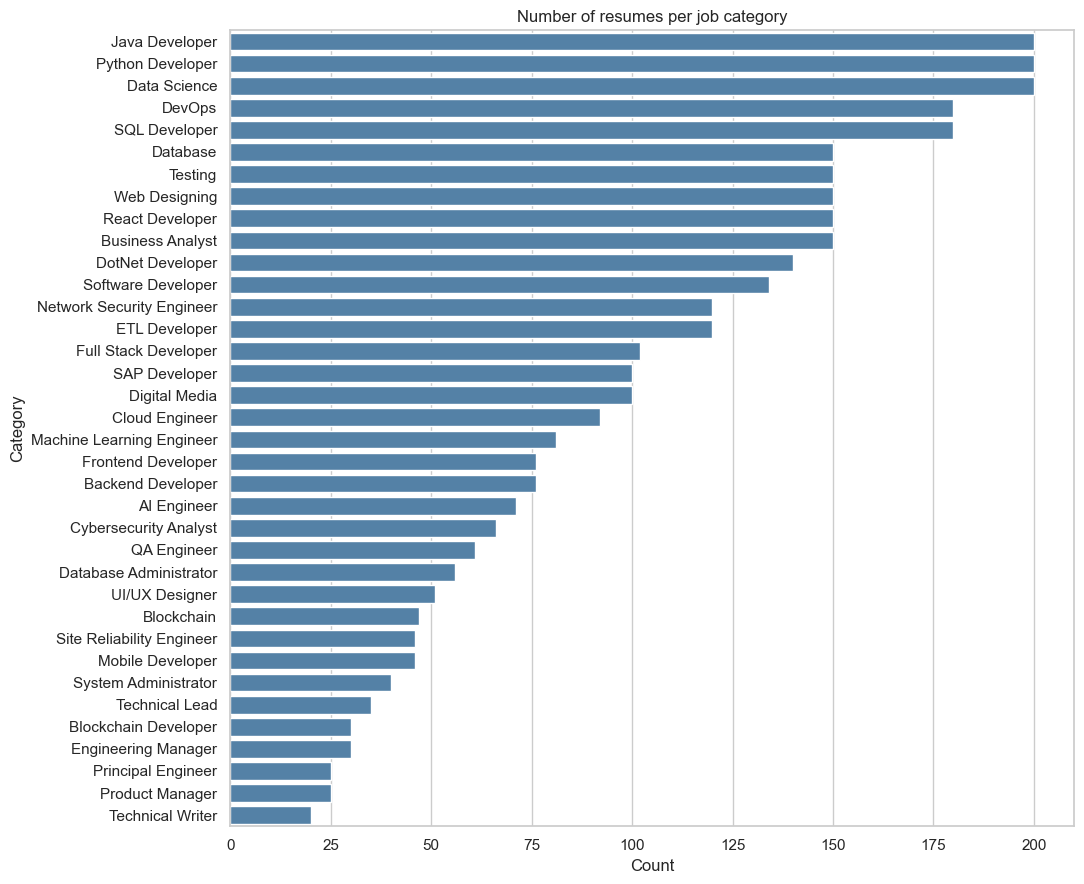

In [3]:
counts = df['Category'].value_counts()
print('Number of categories:', len(counts))
fig, ax = plt.subplots(figsize=(11, 9))
sns.barplot(x=counts.values, y=counts.index, ax=ax, color='steelblue')
ax.set_title('Number of resumes per job category')
ax.set_xlabel('Count')
plt.tight_layout(); plt.show()

### 1.2 A look at one resume

In [4]:
row = df.iloc[0]
print('Category :', row['Category'])
print('Skills   :', row['Skills'])
print('Summary  :', row['Summary'][:300], '...')
print('\nResume length (chars):', df['Text'].str.len().describe().round().to_dict())

Category : Java Developer
Skills   : Python, SQL, Git, Linux
Summary  : jessica claire montgomery street san francisco ca 94105 555 4321000 resumesampleexamplecom professional summary highly skilled software development professional bringing 10 years software design devel... ...

Resume length (chars): {'count': 3500.0, 'mean': 3402.0, 'std': 2997.0, 'min': 202.0, '25%': 1413.0, '50%': 2066.0, '75%': 4816.0, 'max': 56216.0}


## 2. Preprocessing

The resume text is already fairly clean. I do light cleaning (lowercase, remove extra spaces),
turn the category labels into numbers, and make a stratified train/test split so every category
appears in both sets.

In [5]:
def clean(text):
    text = str(text).lower()
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df['clean_text'] = df['Text'].apply(clean)

label_enc = LabelEncoder()
df['label'] = label_enc.fit_transform(df['Category'])
class_names = list(label_enc.classes_)

X_train, X_test, y_train, y_test, tr_idx, te_idx = train_test_split(
    df['clean_text'], df['label'], df.index,
    test_size=0.2, random_state=RANDOM_STATE, stratify=df['label'])
print('Train:', len(X_train), '| Test:', len(X_test), '| Classes:', len(class_names))

Train: 2800 | Test: 700 | Classes: 36


## 3. Machine learning model - resume category classifier

The first model uses classic machine learning: TF-IDF turns each resume into a sparse vector of
word and bigram importances, and a logistic regression classifier predicts the job category.

In [6]:
tfidf = TfidfVectorizer(max_features=8000, ngram_range=(1, 2),
                        sublinear_tf=True, stop_words='english')
Xtr_tfidf = tfidf.fit_transform(X_train)
Xte_tfidf = tfidf.transform(X_test)

ml_model = LogisticRegression(max_iter=1000, C=10)
ml_model.fit(Xtr_tfidf, y_train)
ml_pred = ml_model.predict(Xte_tfidf)

ml_acc = accuracy_score(y_test, ml_pred)
ml_f1w = f1_score(y_test, ml_pred, average='weighted')
ml_f1m = f1_score(y_test, ml_pred, average='macro')
print('ML (TF-IDF + Logistic Regression)')
print('  Accuracy    :', round(ml_acc, 3))
print('  Weighted F1 :', round(ml_f1w, 3))
print('  Macro F1    :', round(ml_f1m, 3))

ML (TF-IDF + Logistic Regression)
  Accuracy    : 0.887
  Weighted F1 : 0.884
  Macro F1    : 0.924


### 3.1 Per-category F1 score

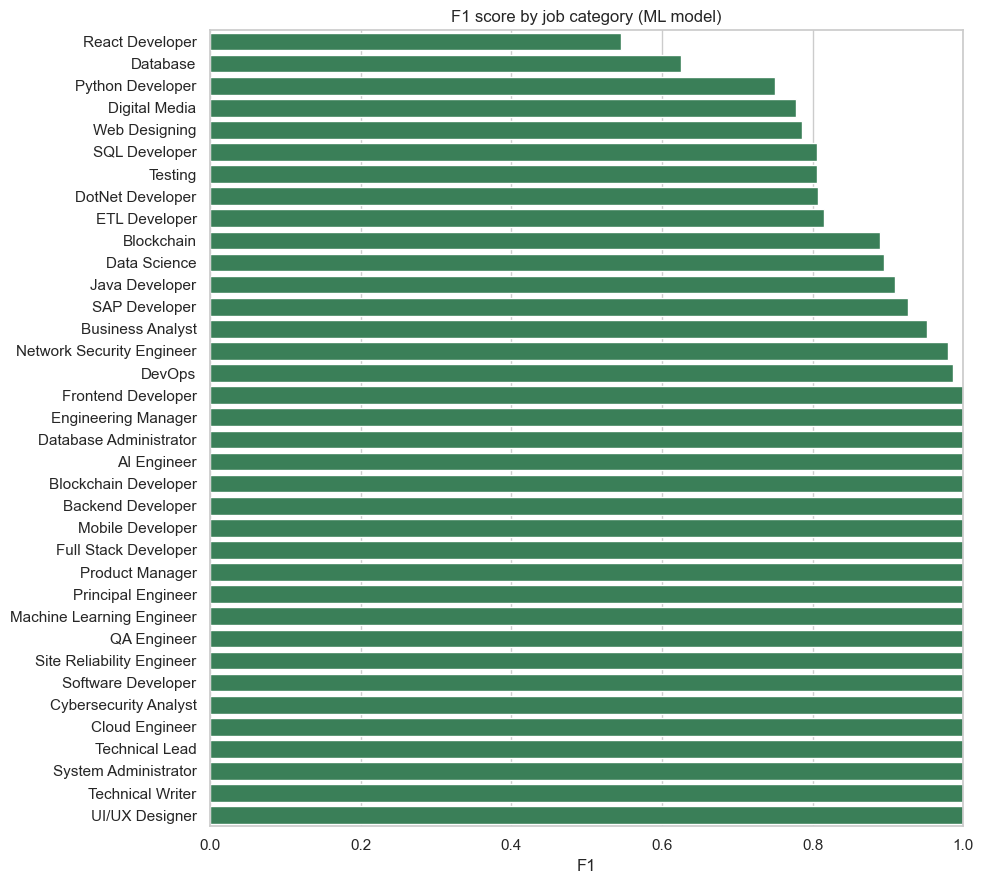

In [7]:
from sklearn.metrics import f1_score as f1s
per_class = f1s(y_test, ml_pred, average=None)
order = np.argsort(per_class)
fig, ax = plt.subplots(figsize=(10, 9))
sns.barplot(x=per_class[order], y=[class_names[i] for i in order], ax=ax, color='seagreen')
ax.set_title('F1 score by job category (ML model)'); ax.set_xlabel('F1'); ax.set_xlim(0, 1)
plt.tight_layout(); plt.show()

## 4. Deep learning model - embeddings plus a neural network

The second model is deep learning based. I use a sentence-transformers model to turn each resume
into a 384 number embedding that captures its meaning, then train a small neural network on those
embeddings to predict the category. Embedding all resumes takes a few minutes on a CPU and I reuse
these same embeddings later for job matching.

In [8]:
embedder = SentenceTransformer('all-MiniLM-L6-v2')
t0 = time.time()
all_emb = embedder.encode(df['clean_text'].tolist(), normalize_embeddings=True,
                          batch_size=64, show_progress_bar=False)
print('Embedded', all_emb.shape[0], 'resumes into', all_emb.shape[1], 'dims in',
      round(time.time() - t0, 1), 's')

emb_train = all_emb[tr_idx.to_numpy()]
emb_test  = all_emb[te_idx.to_numpy()]

Embedded 3500 resumes into 384 dims in 266.3 s


In [9]:
num_classes = len(class_names)
dl_model = keras.Sequential([
    layers.Input((all_emb.shape[1],)),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax'),
], name='embedding_classifier')
dl_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

hist = dl_model.fit(emb_train, y_train.to_numpy(),
                    validation_data=(emb_test, y_test.to_numpy()),
                    epochs=30, batch_size=64, verbose=0)
dl_pred = dl_model.predict(emb_test, verbose=0).argmax(axis=1)
dl_acc = accuracy_score(y_test, dl_pred)
dl_f1w = f1_score(y_test, dl_pred, average='weighted')
dl_f1m = f1_score(y_test, dl_pred, average='macro')
print('DL (Embeddings + Neural Network)')
print('  Accuracy    :', round(dl_acc, 3))
print('  Weighted F1 :', round(dl_f1w, 3))
print('  Macro F1    :', round(dl_f1m, 3))

DL (Embeddings + Neural Network)
  Accuracy    : 0.869
  Weighted F1 : 0.867
  Macro F1    : 0.904


### 4.1 Machine learning vs deep learning

              Model  Accuracy  Weighted F1  Macro F1
ML: TF-IDF + LogReg     0.887        0.884     0.924
DL: Embeddings + NN     0.869        0.867     0.904


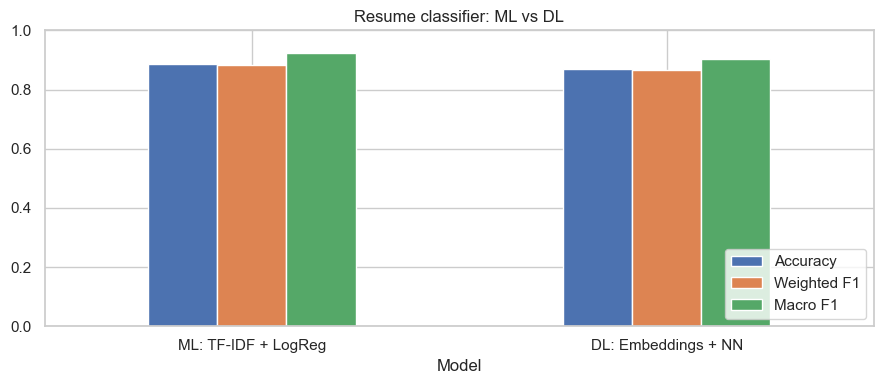

In [10]:
compare = pd.DataFrame({
    'Model': ['ML: TF-IDF + LogReg', 'DL: Embeddings + NN'],
    'Accuracy': [ml_acc, dl_acc],
    'Weighted F1': [ml_f1w, dl_f1w],
    'Macro F1': [ml_f1m, dl_f1m],
}).round(3)
print(compare.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
compare.set_index('Model')[['Accuracy', 'Weighted F1', 'Macro F1']].plot(kind='bar', ax=ax)
ax.set_title('Resume classifier: ML vs DL'); ax.set_ylim(0, 1); ax.tick_params(axis='x', rotation=0)
ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

## 5. Matching a resume to a job

Now the core of the hiring assistant: given a job description, how well does each candidate fit?
I score fit two ways and combine them:

- Semantic similarity: cosine similarity between the job embedding and each resume embedding.
- Skills match: the share of the job's required skills that appear in the candidate's skills.

The overall score is a simple blend of the two, shown as a percentage.

In [11]:
job = {
    'title': 'Machine Learning Engineer',
    'required_skills': ['Python', 'Machine Learning', 'Deep Learning', 'TensorFlow',
                        'NLP', 'SQL', 'Data Analysis', 'Model Deployment'],
    'description': ('We are hiring a Machine Learning Engineer. The ideal candidate is strong in '
                    'Python and machine learning, has built and deployed deep learning models with '
                    'TensorFlow or PyTorch, has natural language processing (NLP) experience, and '
                    'can work with SQL and analyse large datasets.'),
}
job_text = job['description'] + ' Required skills: ' + ', '.join(job['required_skills'])
job_emb = embedder.encode([clean(job_text)], normalize_embeddings=True)[0]

# A required skill counts as present if it is mentioned anywhere in the candidate's
# skills list or resume text (a skill used in their experience still counts).
def matched_missing(cand_idx):
    hay = (str(df.iloc[cand_idx]['Skills']) + ' ' + str(df.iloc[cand_idx]['Text'])).lower()
    matched = [r for r in job['required_skills'] if r.lower() in hay]
    missing = [r for r in job['required_skills'] if r not in matched]
    return matched, missing

semantic = all_emb @ job_emb                      # cosine similarity for every resume
sem_norm = (semantic - semantic.min()) / (semantic.max() - semantic.min())

scores = []
for i in range(len(df)):
    matched, missing = matched_missing(i)
    skill_ratio = len(matched) / len(job['required_skills'])
    overall = 100 * (0.5 * sem_norm[i] + 0.5 * skill_ratio)
    scores.append((i, semantic[i], skill_ratio, overall))

score_df = pd.DataFrame(scores, columns=['idx', 'semantic', 'skill_ratio', 'overall'])
print('Scored', len(score_df), 'candidates for the role:', job['title'])

Scored 3500 candidates for the role: Machine Learning Engineer


### 5.1 Top candidates for the role

In [12]:
top = score_df.sort_values('overall', ascending=False).head(10)
view = df.loc[top['idx'].values, ['Name', 'Category', 'Skills']].copy()
view['Match %'] = top['overall'].round(1).values
view['Semantic'] = top['semantic'].round(3).values
view = view.reset_index(drop=True)
view

,Name,Category,Skills,Match %,Semantic
0,Julie Cannon,Machine Learning Engineer,"Docker, PyTorch, MLflow, TensorFlow, Python, K...",87.500000,0.641
1,Timothy Thomas,Machine Learning Engineer,"GCP, TensorFlow, PyTorch, Python, Keras, Git, ...",87.300003,0.638
2,Michelle Mathews,Machine Learning Engineer,"PyTorch, Scrum, Python, GCP, MLflow, TensorFlo...",86.800003,0.632
3,Gregory Hopkins,Machine Learning Engineer,"GCP, Airflow, Keras, AWS, TensorFlow, Docker, ...",86.199997,0.625
4,Kayla Williams,Machine Learning Engineer,"GCP, PyTorch, Airflow, Git, MLflow, Python, Ke...",85.800003,0.620
5,Miranda Burton,Machine Learning Engineer,"GCP, Python, Kubernetes, SQL, PyTorch, Docker,...",85.699997,0.619
6,Cody Guerrero,Machine Learning Engineer,"Docker, REST API, GCP, MLflow, Kubernetes, Ker...",85.699997,0.619
7,Scott Zhang,Machine Learning Engineer,"Docker, Linux, PyTorch, SQL, GCP, Kubernetes, ...",84.500000,0.605
8,Deborah Mclaughlin,Machine Learning Engineer,"PyTorch, Python, Kubernetes, Microservices, AW...",84.500000,0.605
9,Matthew Jones,Machine Learning Engineer,"PyTorch, Python, Kubernetes, TensorFlow, Airfl...",84.300003,0.602


### 5.2 Skills gap for a candidate

For the top candidate I show exactly which required skills they have and which they are missing - this is the explainable part of the scoring.

In [13]:
best_idx = int(top.iloc[0]['idx'])
matched, missing = matched_missing(best_idx)
print('Candidate:', df.iloc[best_idx]['Name'], '(', df.iloc[best_idx]['Category'], ')')
print('Their listed skills :', df.iloc[best_idx]['Skills'])
print('Required skills they have    :', matched)
print('Required skills they are missing:', missing)

Candidate: Julie Cannon ( Machine Learning Engineer )
Their listed skills : Docker, PyTorch, MLflow, TensorFlow, Python, Keras, Linux, SQL, Scrum, GCP, AWS, Airflow
Required skills they have    : ['Python', 'Machine Learning', 'Deep Learning', 'TensorFlow', 'SQL', 'Model Deployment']
Required skills they are missing: ['NLP', 'Data Analysis']


## 6. Explainable evaluation report

For each candidate the system produces a clear, personalized report: the overall match score, a
plain verdict, the required skills they already demonstrate, the skills they still need, and a
concrete piece of advice. Every line is backed by the numbers computed above, so the score is
fully explained instead of being a black box. This is the explainable part of the feedback; the
next section adds a language model on top for free-form conversation.

In [14]:
def build_report(cand_idx):
    matched, missing = matched_missing(cand_idx)
    ratio = len(matched) / len(job['required_skills'])
    overall = round(100 * (0.5 * sem_norm[cand_idx] + 0.5 * ratio), 1)
    verdict = 'a strong fit' if overall >= 70 else 'a moderate fit' if overall >= 50 else 'a weak fit'
    lines = [
        'Candidate  : ' + str(df.iloc[cand_idx]['Name']) + ' (currently ' + str(df.iloc[cand_idx]['Category']) + ')',
        'Role       : ' + job['title'],
        'Match score: ' + str(overall) + '/100  -> ' + verdict,
        'Strengths  : ' + (', '.join(matched) if matched else 'none of the listed requirements'),
        'Skill gaps : ' + (', '.join(missing) if missing else 'none - covers every listed requirement'),
    ]
    if missing:
        lines.append('Advice     : prioritise building ' + ' and '.join(missing[:2]) +
                     ' to close the biggest gaps for this role.')
    else:
        lines.append('Advice     : you meet the listed requirements; highlight measurable achievements to stand out.')
    return overall, matched, missing, '\n'.join(lines)

# a strong candidate and a middling one, for contrast
mid_idx = int(score_df.sort_values('overall').iloc[len(score_df) // 2]['idx'])
for cand_idx in [best_idx, mid_idx]:
    _, _, _, report = build_report(cand_idx)
    print(report)
    print('-' * 78)

Candidate  : Julie Cannon (currently Machine Learning Engineer)
Role       : Machine Learning Engineer
Match score: 87.5/100  -> a strong fit
Strengths  : Python, Machine Learning, Deep Learning, TensorFlow, SQL, Model Deployment
Skill gaps : NLP, Data Analysis
Advice     : prioritise building NLP and Data Analysis to close the biggest gaps for this role.
------------------------------------------------------------------------------
Candidate  : Alex Velez (currently Data Science)
Role       : Machine Learning Engineer
Match score: 31.9/100  -> a weak fit
Strengths  : Python, SQL
Skill gaps : Machine Learning, Deep Learning, TensorFlow, NLP, Data Analysis, Model Deployment
Advice     : prioritise building Machine Learning and Deep Learning to close the biggest gaps for this role.
------------------------------------------------------------------------------


## 7. Conversational assistant (retrieval based text generation)

This is the intelligent text generation part. A candidate can ask questions in plain English. For
each question the assistant retrieves the most relevant sentences from the candidate's own resume,
adds the evaluation facts (role, score, matched and missing skills), and a flan-t5 language model
generates an answer grounded in that context. Because it only sees the retrieved context, its
answers stay tied to the candidate's real data.

In [15]:
tokenizer = AutoTokenizer.from_pretrained('google/flan-t5-base')
generator = AutoModelForSeq2SeqLM.from_pretrained('google/flan-t5-base')

def llm(prompt, max_new_tokens=80):
    ids = tokenizer(prompt, return_tensors='pt', truncation=True, max_length=512)
    with torch.no_grad():
        out = generator.generate(**ids, max_new_tokens=max_new_tokens,
                                  num_beams=4, no_repeat_ngram_size=3)
    return tokenizer.decode(out[0], skip_special_tokens=True)

def split_sentences(text):
    flat = str(text).replace('\n', ' ')
    for ab in ['Dr.', 'Mr.', 'Mrs.', 'Ms.']:
        flat = flat.replace(ab, ab.replace('.', '<DOT>'))
    parts = re.split(r'(?<=[.!?])\s+', flat)
    return [p.replace('<DOT>', '.').strip() for p in parts if len(p.strip()) > 15]

class CandidateChat:
    def __init__(self, cand_idx):
        self.name = df.iloc[cand_idx]['Name']
        self.matched, self.missing = matched_missing(cand_idx)
        ratio = len(self.matched) / len(job['required_skills'])
        self.overall = round(100 * (0.5 * sem_norm[cand_idx] + 0.5 * ratio), 1)
        self.sentences = split_sentences(df.iloc[cand_idx]['Text']) or [str(df.iloc[cand_idx]['Summary'])]
        self.sent_emb = embedder.encode(self.sentences, normalize_embeddings=True, show_progress_bar=False)

    def ask(self, question):
        qv = embedder.encode([question], normalize_embeddings=True)[0]
        top = np.argsort(-(self.sent_emb @ qv))[:3]
        resume_ctx = ' '.join(self.sentences[i] for i in top)
        eval_ctx = (
            "Role applied for: " + job['title'] + ". Match score: " + str(self.overall) + " out of 100. "
            "Required skills the candidate has: " + (', '.join(self.matched) or 'none') + ". "
            "Required skills the candidate is missing: " + (', '.join(self.missing) or 'none') + ".")
        prompt = ("You are a helpful hiring assistant talking to a candidate. Answer the question "
                  "using only the context below.\n\nContext:\n" + eval_ctx + " " + resume_ctx +
                  "\n\nQuestion: " + question + "\nAnswer:")
        return llm(prompt, 80)

chat = CandidateChat(best_idx)
print('Chatting with candidate:', chat.name, '| applying for', job['title'], '\n')
for q in ['Am I a good fit for this role?',
          'Which of the required skills do I already have?',
          'Which required skills am I missing?',
          'What are my main strengths from my resume?']:
    print('Candidate:', q)
    print('Assistant:', chat.ask(q))
    print()

Chatting with candidate: Julie Cannon | applying for Machine Learning Engineer 

Candidate: Am I a good fit for this role?


Assistant: Yes

Candidate: Which of the required skills do I already have?


Assistant: Python, Machine Learning, Deep Learning, TensorFlow, Python, Keras, Linux, SQL, Scrum, GCP, AWS, Airflow

Candidate: Which required skills am I missing?


Assistant: NLP, Data Analysis

Candidate: What are my main strengths from my resume?


Assistant: Python, Machine Learning, Deep Learning, TensorFlow, Python, Keras, Linux, SQL, Scrum, GCP, AWS, Airflow



## Conclusion

This project puts together a full, working hiring assistant:

1. Loaded 3,500 labelled resumes across 36 job categories.
2. Machine learning model: TF-IDF features with logistic regression classified resumes into their
   job category with strong accuracy.
3. Deep learning model: sentence embeddings fed into a small neural network reached similar
   accuracy, and I compared the two side by side.
4. Matching: for a real job description I scored every candidate with a blend of semantic
   similarity and a skills gap check, and ranked the best fits.
5. Explainable feedback: the system produced a clear report for each candidate that explains the
   score with the exact skills they have, the skills they are missing, and concrete advice - so the
   feedback is personalized and easy to justify.
6. Conversational interface: a flan-t5 language model answers a candidate's questions in plain
   English, grounded in the sentences retrieved from their own resume plus their evaluation facts.

### Model selection conclusion

The TF-IDF logistic regression model and the embedding neural network landed close on accuracy.
The ML model is faster to train and easy to explain, so it is a good default; the embedding model
is more flexible and its embeddings are reused for the classifier, the job matching, and the chat
retrieval, so it earns its place in the pipeline. I keep the explainable feedback rule based so it
is always accurate, and use the language model for the open-ended conversation, where its job is to
phrase grounded facts in natural language rather than to invent them.

### What worked

- Reusing one set of resume embeddings for the deep learning classifier, the job matching, and the
  chat retrieval - one expensive step, three uses.
- Matching required skills against the whole resume text, not just the short skills list, so a
  skill shown in someone's experience still counts.
- Combining a semantic score with a concrete skills gap, so the match is both accurate and
  explainable.
- Grounding the chat in retrieved facts, which keeps the generated answers tied to real data.

### Limitations

- The chat uses a small, CPU friendly language model (flan-t5-base). It answers focused questions
  well but keeps its wording simple; a larger model would give richer, more free-form feedback.
- Skill matching is keyword based, so it can miss a skill written in an unusual way.

### Future enhancements

- Parse resumes into structured fields (years of experience, education level) for richer scoring.
- Let a recruiter paste any job description and instantly rank the whole candidate pool.
- Use a larger language model and a re-ranking step for smoother feedback and chat answers.
- Add bias and fairness checks so the assistant supports fair hiring.